In [7]:
import pandas as pd
import numpy as np
from pyomo.environ import *
import sys
import os

# Add project path (parent folder where all files are)
sys.path.append('/Users/manostsili/Desktop/dtu/courses/decision making under uncertainty /assignment_DC')

# Load system characteristics
import v2_SystemCharacteristics as sc

# Get all parameters
params = sc.get_fixed_data()

# Print to verify
print("Parameters loaded successfully!")
print(f"Number of timeslots: {params['num_timeslots']}")
print(f"Max heating power: {params['heating_max_power']}")
print(f"Ventilation power: {params['ventilation_power']}")
print(f"Temp thresholds: Low={params['temp_min_comfort_threshold']}, OK={params['temp_OK_threshold']}, High={params['temp_max_comfort_threshold']}")
print(f"Humidity threshold: {params['humidity_threshold']}")
print(f"Vent min up time: {params['vent_min_up_time']}")
print(f"Outdoor temperatures: {params['outdoor_temperature']}")

Parameters loaded successfully!
Number of timeslots: 10
Max heating power: 3.0
Ventilation power: 2.0
Temp thresholds: Low=18.0, OK=22.0, High=26.0
Humidity threshold: 70.0
Vent min up time: 3
Outdoor temperatures: [np.float64(-3.0), np.float64(-2.4270509831248424), np.float64(-0.9270509831248421), np.float64(0.9270509831248421), np.float64(2.4270509831248424), np.float64(3.0), np.float64(2.4270509831248424), np.float64(0.9270509831248426), np.float64(-0.9270509831248419), np.float64(-2.427050983124842)]


In [8]:
# Define path to data files
data_path = '/Users/manostsili/Desktop/dtu/courses/decision making under uncertainty /assignment_DC'

# Load CSV files
price_data = pd.read_csv(f'{data_path}/v2_PriceData.csv')
occ_room1 = pd.read_csv(f'{data_path}/OccupancyRoom1.csv')
occ_room2 = pd.read_csv(f'{data_path}/OccupancyRoom2.csv')

# Print shapes to verify
print(f"Price data shape: {price_data.shape}")
print(f"Occupancy Room 1 shape: {occ_room1.shape}")
print(f"Occupancy Room 2 shape: {occ_room2.shape}")

# Print first row to verify
print(f"\nFirst row of price data:")
print(price_data.iloc[0])
print(f"\nFirst row of occupancy room 1:")
print(occ_room1.iloc[0])

Price data shape: (100, 11)
Occupancy Room 1 shape: (100, 10)
Occupancy Room 2 shape: (100, 10)

First row of price data:
Previous price at the first timeslot    5.831304
1                                       4.311189
2                                       3.524664
3                                       3.027218
4                                       3.082560
5                                       3.308368
6                                       4.192301
7                                       5.470418
8                                       6.330840
9                                       7.047661
10                                      6.712330
Name: 0, dtype: float64

First row of occupancy room 1:
0    32.969098
1    34.098942
2    33.617007
3    35.445151
4    32.503181
5    30.244813
6    24.592165
7    25.693216
8    29.555435
9    26.972916
Name: 0, dtype: float64


In [9]:
# Extract data for day 0 (first day) as example
day = 0

# Previous price (needed as initial condition)
price_previous = price_data.iloc[day, 0]

# Prices for hours 1-10
prices = price_data.iloc[day, 1:].values  # array of 10 values

# Occupancies for hours 0-9
occ1 = occ_room1.iloc[day, :].values  # array of 10 values
occ2 = occ_room2.iloc[day, :].values  # array of 10 values

print(f"Previous price: {price_previous:.2f}")
print(f"Prices: {prices}")
print(f"Occupancy Room 1: {occ1}")
print(f"Occupancy Room 2: {occ2}")

Previous price: 5.83
Prices: [4.31118851 3.52466406 3.02721796 3.08255973 3.30836785 4.19230114
 5.47041802 6.33083988 7.04766121 6.71233027]
Occupancy Room 1: [32.96909766 34.09894158 33.6170068  35.44515143 32.50318123 30.24481328
 24.59216549 25.69321559 29.55543502 26.9729157 ]
Occupancy Room 2: [15.47104087 19.41699474 20.76037968 24.82750511 30.         29.73411686
 29.67855934 25.43884524 22.52349111 18.75010822]


In [13]:
def solve_milp(prices, occ1, occ2, params):
    
    # Extract parameters
    T = params['num_timeslots']
    R = [1, 2]
    times = range(T)
    P_max = params['heating_max_power']
    P_vent = params['ventilation_power']
    zeta_exch = params['heat_exchange_coeff']
    zeta_loss = params['thermal_loss_coeff']
    zeta_conv = params['heating_efficiency_coeff']
    zeta_cool = params['heat_vent_coeff']
    zeta_occ  = params['heat_occupancy_coeff']
    eta_occ   = params['humidity_occupancy_coeff']
    eta_vent  = params['humidity_vent_coeff']
    T_low     = params['temp_min_comfort_threshold']
    T_ok      = params['temp_OK_threshold']
    T_high    = params['temp_max_comfort_threshold']
    H_high    = params['humidity_threshold']
    U_vent    = params['vent_min_up_time']
    T_out     = params['outdoor_temperature']
    T1_init   = params['T1']
    T2_init   = params['T2']
    H_init    = params['H']
    M_temp    = 100
    M_hum     = 200
    
    occ = {(1, t): occ1[t] for t in times}
    occ.update({(2, t): occ2[t] for t in times})
    
    # Build Pyomo Model
    model = ConcreteModel()
    model.T = RangeSet(0, T-1)
    model.R = Set(initialize=[1, 2])
    
    # Variables
    model.p      = Var(model.R, model.T, domain=NonNegativeReals, bounds=(0, P_max))
    model.Temp   = Var(model.R, model.T, domain=Reals)
    model.H      = Var(model.T, domain=Reals)
    model.v      = Var(model.T, domain=Binary)
    model.s      = Var(model.T, domain=Binary)
    model.y_low  = Var(model.R, model.T, domain=Binary)
    model.y_ok   = Var(model.R, model.T, domain=Binary)
    model.y_high = Var(model.R, model.T, domain=Binary)
    model.u      = Var(model.R, model.T, domain=Binary)
    
    # Objective Function
    def obj_rule(model):
        return sum(
            prices[t] * (
                sum(model.p[r, t] for r in model.R) +
                P_vent * model.v[t]
            )
            for t in model.T
        )
    model.obj = Objective(rule=obj_rule, sense=minimize)
    
    # Initial Conditions
    model.init_T1 = Constraint(expr=model.Temp[1, 0] == T1_init)
    model.init_T2 = Constraint(expr=model.Temp[2, 0] == T2_init)
    model.init_H  = Constraint(expr=model.H[0] == H_init)
    
    # Temperature Dynamics
    def temp_dynamics(model, r, t):
        if t == 0:
            return Constraint.Skip
        r_other = 2 if r == 1 else 1
        return model.Temp[r, t] == (
            model.Temp[r, t-1]
            + zeta_exch * (model.Temp[r_other, t-1] - model.Temp[r, t-1])
            - zeta_loss * (model.Temp[r, t-1] - T_out[t-1])
            + zeta_conv * model.p[r, t-1]
            - zeta_cool * model.v[t-1]
            + zeta_occ  * occ[r, t-1]
        )
    model.temp_dynamics = Constraint(model.R, model.T, rule=temp_dynamics)
    
    # Humidity Dynamics
    def hum_dynamics(model, t):
        if t == 0:
            return Constraint.Skip
        return model.H[t] == (
            model.H[t-1]
            + eta_occ * sum(occ[r, t-1] for r in R)
            - eta_vent * model.v[t-1]
        )
    model.hum_dynamics = Constraint(model.T, rule=hum_dynamics)
    
    # Detecting T above T_high
    def y_high_upper(model, r, t):
        return model.Temp[r, t] >= T_high - M_temp * (1 - model.y_high[r, t])
    model.y_high_upper = Constraint(model.R, model.T, rule=y_high_upper)

    def y_high_lower(model, r, t):
        return model.Temp[r, t] <= T_high + M_temp * model.y_high[r, t]
    model.y_high_lower = Constraint(model.R, model.T, rule=y_high_lower)
    
    # Detecting T below T_low
    def y_low_upper(model, r, t):
        return model.Temp[r, t] <= T_low + M_temp * (1 - model.y_low[r, t])
    model.y_low_upper = Constraint(model.R, model.T, rule=y_low_upper)

    def y_low_lower(model, r, t):
        return model.Temp[r, t] >= T_low - M_temp * model.y_low[r, t]
    model.y_low_lower = Constraint(model.R, model.T, rule=y_low_lower)
    
    # Detecting T above T_ok
    def y_ok_upper(model, r, t):
        return model.Temp[r, t] >= T_ok - M_temp * (1 - model.y_ok[r, t])
    model.y_ok_upper = Constraint(model.R, model.T, rule=y_ok_upper)

    def y_ok_lower(model, r, t):
        return model.Temp[r, t] <= T_ok + M_temp * model.y_ok[r, t]
    model.y_ok_lower = Constraint(model.R, model.T, rule=y_ok_lower)
    
    # Triggering Overrule Controller
    def overrule_trigger(model, r, t):
        return model.u[r, t] >= model.y_low[r, t]
    model.overrule_trigger = Constraint(model.R, model.T, rule=overrule_trigger)

    def overrule_memory(model, r, t):
        if t == 0:
            return Constraint.Skip
        return model.u[r, t] <= model.u[r, t-1] + model.y_low[r, t]
    model.overrule_memory = Constraint(model.R, model.T, rule=overrule_memory)
    
    # De-activating Overrule Controller
    def overrule_persist(model, r, t):
        if t == 0:
            return Constraint.Skip
        return model.u[r, t] >= model.u[r, t-1] - model.y_ok[r, t]
    model.overrule_persist = Constraint(model.R, model.T, rule=overrule_persist)

    def overrule_deactivate(model, r, t):
        if t == 0:
            return Constraint.Skip
        return model.u[r, t] <= 1 - model.y_ok[r, t]
    model.overrule_deactivate = Constraint(model.R, model.T, rule=overrule_deactivate)
    
    # Overrule Forcing Heater to Maximum
    def overrule_max(model, r, t):
        return model.p[r, t] >= P_max * model.u[r, t]
    model.overrule_max = Constraint(model.R, model.T, rule=overrule_max)
    
    # Overrule Forcing Heater to Zero
    def overrule_zero(model, r, t):
        return model.p[r, t] <= P_max * (1 - model.y_high[r, t])
    model.overrule_zero = Constraint(model.R, model.T, rule=overrule_zero)
    
    # Ventilation Startup Detection
    def startup_detect1(model, t):
        return model.s[t] >= model.v[t] - (model.v[t-1] if t > 0 else 0)
    model.startup_detect1 = Constraint(model.T, rule=startup_detect1)

    def startup_detect2(model, t):
        return model.s[t] <= model.v[t]
    model.startup_detect2 = Constraint(model.T, rule=startup_detect2)

    def startup_detect3(model, t):
        if t == 0:
            return Constraint.Skip
        return model.s[t] <= 1 - model.v[t-1]
    model.startup_detect3 = Constraint(model.T, rule=startup_detect3)
    
    # Ventilation Minimum Up-Time
    def vent_uptime(model, t):
        horizon = min(t + U_vent, T)
        duration = min(U_vent, T - t)
        return sum(model.v[tau] for tau in range(t, horizon)) >= duration * model.s[t]
    model.vent_uptime = Constraint(model.T, rule=vent_uptime)
    
    # Humidity Triggered Ventilation
    def hum_vent(model, t):
        return model.H[t] <= H_high + M_hum * model.v[t]
    model.hum_vent = Constraint(model.T, rule=hum_vent)
    
    # -------------------------
    # Solve the model
    # -------------------------
    solver = SolverFactory('gurobi')
    result = solver.solve(model, tee=False)
    
    # Extract optimal cost
    optimal_cost = value(model.obj)
    
    return optimal_cost

# Test with day 0
cost = solve_milp(prices, occ1, occ2, params)
print(f"Day 0 cost: {cost:.2f}")

Day 0 cost: 110.45


In [14]:
# Solve for all 100 days
daily_costs = []

for day in range(100):
    prices_day = price_data.iloc[day, 1:].values
    occ1_day   = occ_room1.iloc[day, :].values
    occ2_day   = occ_room2.iloc[day, :].values
    
    cost = solve_milp(prices_day, occ1_day, occ2_day, params)
    daily_costs.append(cost)
    
    print(f"Day {day+1}/100 — Cost: {cost:.2f}")

# Average cost
average_cost = np.mean(daily_costs)

Day 1/100 — Cost: 110.45
Day 2/100 — Cost: 145.96
Day 3/100 — Cost: 193.19
Day 4/100 — Cost: 124.75
Day 5/100 — Cost: 161.27
Day 6/100 — Cost: 47.44
Day 7/100 — Cost: 221.82
Day 8/100 — Cost: 212.50
Day 9/100 — Cost: 105.98
Day 10/100 — Cost: 152.97
Day 11/100 — Cost: 13.52
Day 12/100 — Cost: 150.57
Day 13/100 — Cost: 191.78
Day 14/100 — Cost: 215.21
Day 15/100 — Cost: 26.30
Day 16/100 — Cost: 100.23
Day 17/100 — Cost: 6.62
Day 18/100 — Cost: 182.83
Day 19/100 — Cost: 141.37
Day 20/100 — Cost: 88.04
Day 21/100 — Cost: 139.43
Day 22/100 — Cost: 133.36
Day 23/100 — Cost: 90.54
Day 24/100 — Cost: 101.61
Day 25/100 — Cost: 70.24
Day 26/100 — Cost: 114.31
Day 27/100 — Cost: 110.16
Day 28/100 — Cost: 102.05
Day 29/100 — Cost: 161.21
Day 30/100 — Cost: 187.00
Day 31/100 — Cost: 48.65
Day 32/100 — Cost: 179.70
Day 33/100 — Cost: 165.25
Day 34/100 — Cost: 194.93
Day 35/100 — Cost: 182.23
Day 36/100 — Cost: 261.08
Day 37/100 — Cost: 60.81
Day 38/100 — Cost: 13.57
Day 39/100 — Cost: 46.51
Day 40/

In [15]:
print(f"Average daily electricity cost: {np.mean(daily_costs):.2f}")
print(f"Min daily cost: {np.min(daily_costs):.2f}")
print(f"Max daily cost: {np.max(daily_costs):.2f}")

Average daily electricity cost: 129.01
Min daily cost: 6.62
Max daily cost: 261.08


In [20]:
def solve_milp_with_results(prices, occ1, occ2, params):
    
    T = params['num_timeslots']
    R = [1, 2]
    times = range(T)
    P_max = params['heating_max_power']
    P_vent = params['ventilation_power']
    zeta_exch = params['heat_exchange_coeff']
    zeta_loss = params['thermal_loss_coeff']
    zeta_conv = params['heating_efficiency_coeff']
    zeta_cool = params['heat_vent_coeff']
    zeta_occ  = params['heat_occupancy_coeff']
    eta_occ   = params['humidity_occupancy_coeff']
    eta_vent  = params['humidity_vent_coeff']
    T_low     = params['temp_min_comfort_threshold']
    T_ok      = params['temp_OK_threshold']
    T_high    = params['temp_max_comfort_threshold']
    H_high    = params['humidity_threshold']
    U_vent    = params['vent_min_up_time']
    T_out     = params['outdoor_temperature']
    T1_init   = params['T1']
    T2_init   = params['T2']
    H_init    = params['H']
    M_temp    = 100
    M_hum     = 200
    
    occ = {(1, t): occ1[t] for t in times}
    occ.update({(2, t): occ2[t] for t in times})
    
    model = ConcreteModel()
    model.T = RangeSet(0, T-1)
    model.R = Set(initialize=[1, 2])
    
    model.p      = Var(model.R, model.T, domain=NonNegativeReals, bounds=(0, P_max))
    model.Temp   = Var(model.R, model.T, domain=Reals)
    model.H      = Var(model.T, domain=Reals)
    model.v      = Var(model.T, domain=Binary)
    model.s      = Var(model.T, domain=Binary)
    model.y_low  = Var(model.R, model.T, domain=Binary)
    model.y_ok   = Var(model.R, model.T, domain=Binary)
    model.y_high = Var(model.R, model.T, domain=Binary)
    model.u      = Var(model.R, model.T, domain=Binary)
    
    def obj_rule(model):
        return sum(
            prices[t] * (
                sum(model.p[r, t] for r in model.R) +
                P_vent * model.v[t]
            )
            for t in model.T
        )
    model.obj = Objective(rule=obj_rule, sense=minimize)
    
    model.init_T1 = Constraint(expr=model.Temp[1, 0] == T1_init)
    model.init_T2 = Constraint(expr=model.Temp[2, 0] == T2_init)
    model.init_H  = Constraint(expr=model.H[0] == H_init)
    
    def temp_dynamics(model, r, t):
        if t == 0:
            return Constraint.Skip
        r_other = 2 if r == 1 else 1
        return model.Temp[r, t] == (
            model.Temp[r, t-1]
            + zeta_exch * (model.Temp[r_other, t-1] - model.Temp[r, t-1])
            - zeta_loss * (model.Temp[r, t-1] - T_out[t-1])
            + zeta_conv * model.p[r, t-1]
            - zeta_cool * model.v[t-1]
            + zeta_occ  * occ[r, t-1]
        )
    model.temp_dynamics = Constraint(model.R, model.T, rule=temp_dynamics)
    
    def hum_dynamics(model, t):
        if t == 0:
            return Constraint.Skip
        return model.H[t] == (
            model.H[t-1]
            + eta_occ * sum(occ[r, t-1] for r in R)
            - eta_vent * model.v[t-1]
        )
    model.hum_dynamics = Constraint(model.T, rule=hum_dynamics)
    
    def y_high_upper(model, r, t):
        return model.Temp[r, t] >= T_high - M_temp * (1 - model.y_high[r, t])
    model.y_high_upper = Constraint(model.R, model.T, rule=y_high_upper)

    def y_high_lower(model, r, t):
        return model.Temp[r, t] <= T_high + M_temp * model.y_high[r, t]
    model.y_high_lower = Constraint(model.R, model.T, rule=y_high_lower)
    
    def y_low_upper(model, r, t):
        return model.Temp[r, t] <= T_low + M_temp * (1 - model.y_low[r, t])
    model.y_low_upper = Constraint(model.R, model.T, rule=y_low_upper)

    def y_low_lower(model, r, t):
        return model.Temp[r, t] >= T_low - M_temp * model.y_low[r, t]
    model.y_low_lower = Constraint(model.R, model.T, rule=y_low_lower)
    
    def y_ok_upper(model, r, t):
        return model.Temp[r, t] >= T_ok - M_temp * (1 - model.y_ok[r, t])
    model.y_ok_upper = Constraint(model.R, model.T, rule=y_ok_upper)

    def y_ok_lower(model, r, t):
        return model.Temp[r, t] <= T_ok + M_temp * model.y_ok[r, t]
    model.y_ok_lower = Constraint(model.R, model.T, rule=y_ok_lower)
    
    def overrule_trigger(model, r, t):
        return model.u[r, t] >= model.y_low[r, t]
    model.overrule_trigger = Constraint(model.R, model.T, rule=overrule_trigger)

    def overrule_memory(model, r, t):
        if t == 0:
            return Constraint.Skip
        return model.u[r, t] <= model.u[r, t-1] + model.y_low[r, t]
    model.overrule_memory = Constraint(model.R, model.T, rule=overrule_memory)
    
    def overrule_persist(model, r, t):
        if t == 0:
            return Constraint.Skip
        return model.u[r, t] >= model.u[r, t-1] - model.y_ok[r, t]
    model.overrule_persist = Constraint(model.R, model.T, rule=overrule_persist)

    def overrule_deactivate(model, r, t):
        if t == 0:
            return Constraint.Skip
        return model.u[r, t] <= 1 - model.y_ok[r, t]
    model.overrule_deactivate = Constraint(model.R, model.T, rule=overrule_deactivate)
    
    def overrule_max(model, r, t):
        return model.p[r, t] >= P_max * model.u[r, t]
    model.overrule_max = Constraint(model.R, model.T, rule=overrule_max)
    
    def overrule_zero(model, r, t):
        return model.p[r, t] <= P_max * (1 - model.y_high[r, t])
    model.overrule_zero = Constraint(model.R, model.T, rule=overrule_zero)
    
    def startup_detect1(model, t):
        return model.s[t] >= model.v[t] - (model.v[t-1] if t > 0 else 0)
    model.startup_detect1 = Constraint(model.T, rule=startup_detect1)

    def startup_detect2(model, t):
        return model.s[t] <= model.v[t]
    model.startup_detect2 = Constraint(model.T, rule=startup_detect2)

    def startup_detect3(model, t):
        if t == 0:
            return Constraint.Skip
        return model.s[t] <= 1 - model.v[t-1]
    model.startup_detect3 = Constraint(model.T, rule=startup_detect3)
    
    def vent_uptime(model, t):
        horizon = min(t + U_vent, T)
        duration = min(U_vent, T - t)
        return sum(model.v[tau] for tau in range(t, horizon)) >= duration * model.s[t]
    model.vent_uptime = Constraint(model.T, rule=vent_uptime)
    
    def hum_vent(model, t):
        return model.H[t] <= H_high + M_hum * model.v[t]
    model.hum_vent = Constraint(model.T, rule=hum_vent)
    
    # Solve
    solver = SolverFactory('gurobi')
    solver.solve(model, tee=False)
    
    # Return results in format expected by plot_HV_results
    results = {
        "Temp_r1": [value(model.Temp[1, t]) for t in range(T)],
        "Temp_r2": [value(model.Temp[2, t]) for t in range(T)],
        "h_r1":    [value(model.p[1, t]) for t in range(T)],
        "h_r2":    [value(model.p[2, t]) for t in range(T)],
        "v":       [value(model.v[t]) for t in range(T)],
        "Hum":     [value(model.H[t]) for t in range(T)],
        "price":   list(prices),
        "Occ_r1":  list(occ1),
        "Occ_r2":  list(occ2),
    }
    return results

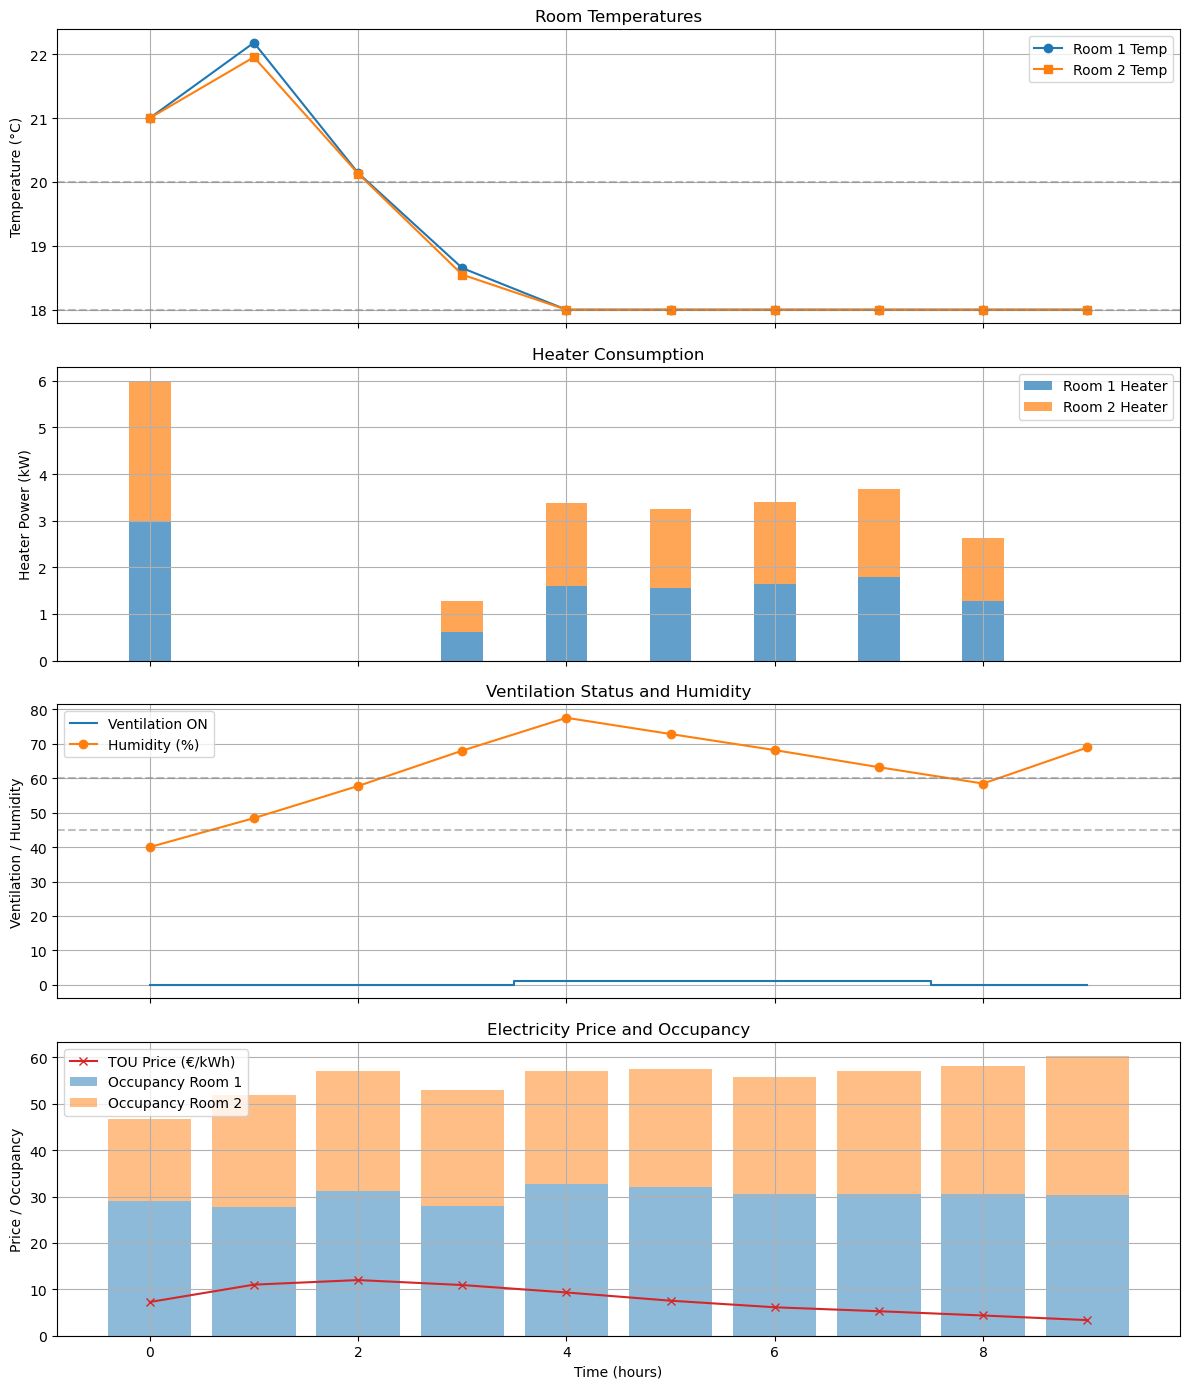

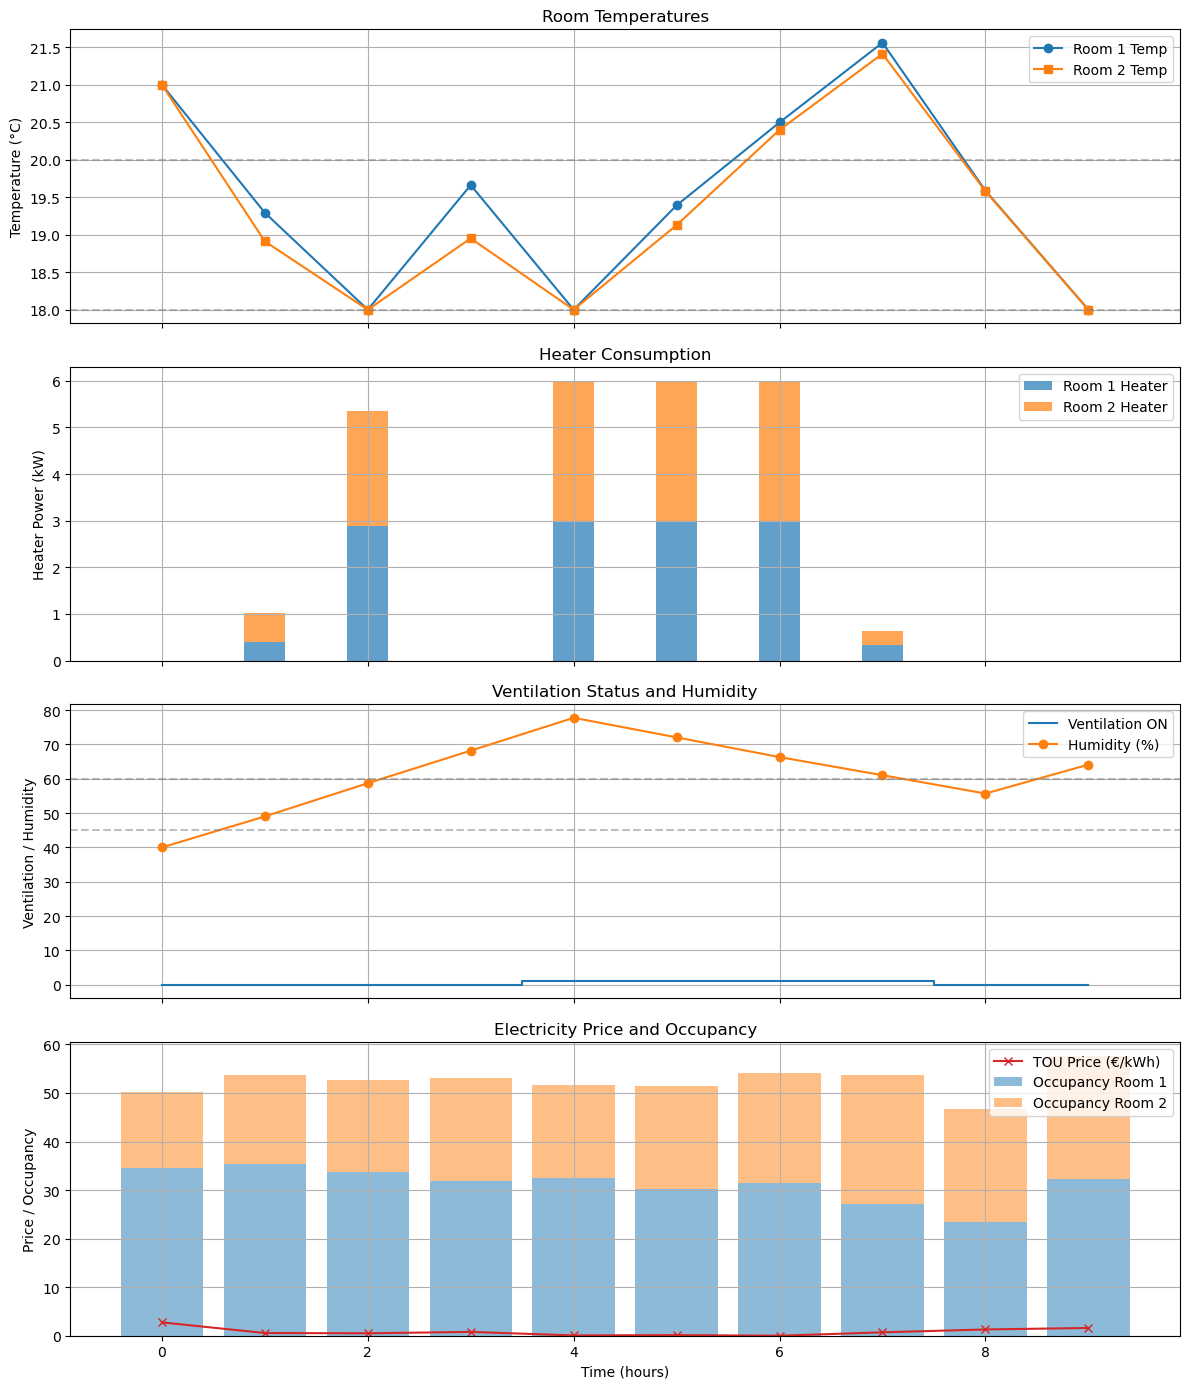

In [21]:
# Import plotting function
sys.path.append('/Users/manostsili/Desktop/dtu/courses/decision making under uncertainty /assignment_DC')
from PlotsRestaurant import plot_HV_results

# Day 7 (index 6) - expensive day
prices_day7 = price_data.iloc[6, 1:].values
occ1_day7   = occ_room1.iloc[6, :].values
occ2_day7   = occ_room2.iloc[6, :].values
results_day7 = solve_milp_with_results(prices_day7, occ1_day7, occ2_day7, params)
plot_HV_results(results_day7, filename="day7_results.png")

# Day 17 (index 16) - cheapest day
prices_day17 = price_data.iloc[16, 1:].values
occ1_day17   = occ_room1.iloc[16, :].values
occ2_day17   = occ_room2.iloc[16, :].values
results_day17 = solve_milp_with_results(prices_day17, occ1_day17, occ2_day17, params)
plot_HV_results(results_day17, filename="day17_results.png")